In [20]:
import pandas as pd
import numpy as np
from lifelines import KaplanMeierFitter, CoxPHFitter

# 1. Wczytanie i standaryzacja
df = pd.read_csv("SEER Breast Cancer Dataset Cleaned.csv")
df.columns = [c.strip() for c in df.columns]

# Etykieta i receptory
df['Event'] = (df['Status'].str.strip() == 'Dead').astype(int)
df['ER_Pos'] = (df['Estrogen Status'].str.strip() == 'Positive').astype(int)
df['PR_Pos'] = (df['Progesterone Status'].str.strip() == 'Positive').astype(int)

# Mapowanie złośliwości (Grade)
grade_map = {
    'Well differentiated; Grade I': 1,
    'Moderately differentiated; Grade II': 2,
    'Poorly differentiated; Grade III': 3,
    'Undifferentiated; anaplastic; Grade IV': 4
}
df['Grade_Num'] = df['Grade'].map(grade_map)

# Ekstrakcja stadiów T i N
t_col = 'T Stage' if 'T Stage' in df.columns else 'T Stage '
n_col = 'N Stage' if 'N Stage' in df.columns else 'N Stage '
df['T_Stage_Num'] = df[t_col].astype(str).str.extract(r'(\d+)').astype(float)
df['N_Stage_Num'] = df[n_col].astype(str).str.extract(r'(\d+)').astype(float)

# Zbalansowany zestaw cech (bez LNR i bez nieistotnego Tumor Size)
features = [
    'Age',
    'Tumor Size',  
    'T_Stage_Num',
    'N_Stage_Num',
    'Grade_Num',
    'Regional Node Examined',
    'Reginol Node Positive',
    'ER_Pos',
    'PR_Pos',
    'Survival Months',
    'Event'
]
stat_df = df[features].dropna()

# --- FILAR 1: Baza populacyjna (Kaplan-Meier) ---
kmf = KaplanMeierFitter()
kmf.fit(stat_df['Survival Months'], event_observed=stat_df['Event'])
baseline_5yr = kmf.predict(60)
print("--- Filar 1: Baza populacyjna (KM) ---")
print(f"Średnie 5-letnie przeżycie w populacji ogólnej: {baseline_5yr * 100:.1f}%\n")

# --- FILAR 2: Model Coxa ze stabilizacją L2 ---
cph = CoxPHFitter(penalizer=0.01)
cph.fit(stat_df, duration_col='Survival Months', event_col='Event')

print("--- Filar 2: Model Proporcjonalnego Hazardu Coxa ---")
print(f"C-index modelu Coxa: {cph.concordance_index_:.3f}\n")

# Tabela wskaźników HR
hr_table = cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']]
hr_table.columns = ['HR', '95% CI Lower', '95% CI Upper', 'p-value']
print(hr_table.round(3))

# --- FILAR 3: Predykcja dla pacjentki testowej ---
przykladowy_pacjent = stat_df.iloc[[0]].drop(columns=['Survival Months', 'Event'])
surv_fn = cph.predict_survival_function(przykladowy_pacjent)
closest_idx = np.abs(surv_fn.index - 60).argmin()
pred_cox_5yr = float(surv_fn.iloc[closest_idx].values[0])

print(f"\nPredykcja Coxa (5 lat) dla pacjentki testowej: {pred_cox_5yr * 100:.1f}%")

--- Filar 1: Baza populacyjna (KM) ---
Średnie 5-letnie przeżycie w populacji ogólnej: 88.1%

--- Filar 2: Model Proporcjonalnego Hazardu Coxa ---
C-index modelu Coxa: 0.736

                           HR  95% CI Lower  95% CI Upper  p-value
covariate                                                         
Age                     1.020         1.011         1.029    0.000
Tumor Size              1.001         0.996         1.005    0.781
T_Stage_Num             1.299         1.133         1.490    0.000
N_Stage_Num             1.406         1.208         1.636    0.000
Grade_Num               1.471         1.293         1.673    0.000
Regional Node Examined  0.972         0.961         0.983    0.000
Reginol Node Positive   1.054         1.034         1.074    0.000
ER_Pos                  0.509         0.394         0.658    0.000
PR_Pos                  0.631         0.516         0.771    0.000

Predykcja Coxa (5 lat) dla pacjentki testowej: 86.2%


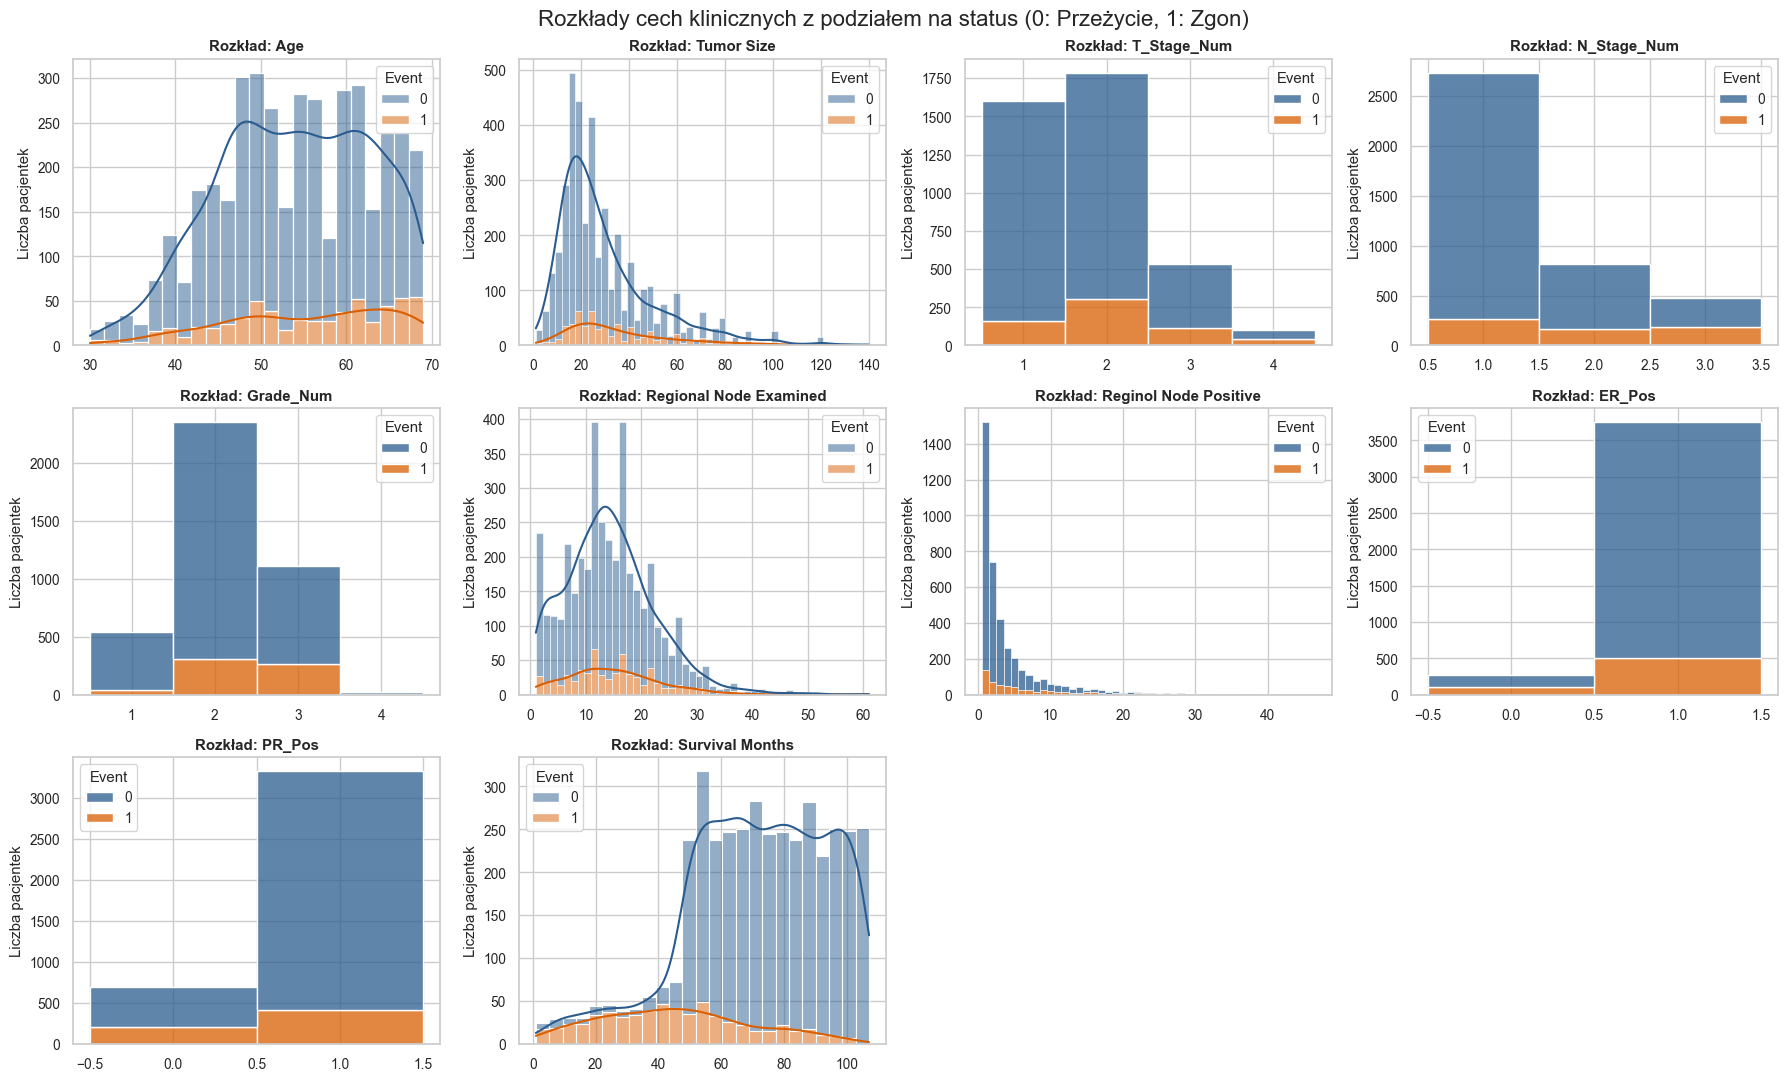

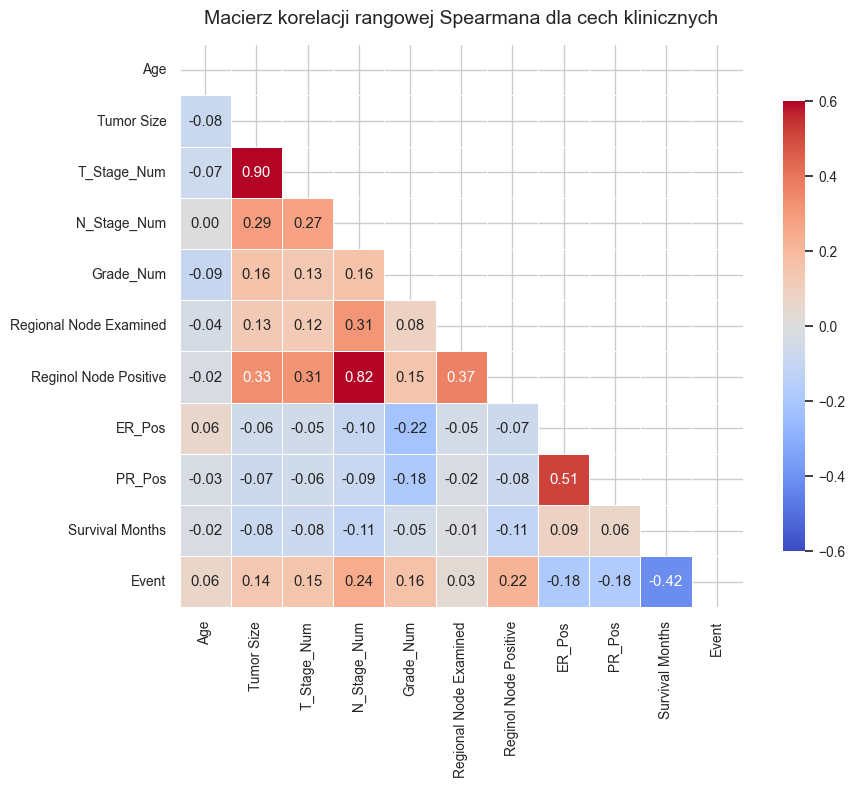

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Histogramy z rozkładami cech (z podziałem na status przeżycia)
sns.set_theme(style="whitegrid", font_scale=0.9)
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()

cols_to_plot = [
    'Age', 'Tumor Size', 'T_Stage_Num', 'N_Stage_Num',
    'Grade_Num', 'Regional Node Examined', 'Reginol Node Positive',
    'ER_Pos', 'PR_Pos', 'Survival Months'
]

palette = {0: '#2b5c8f', 1: '#d95f02'}  # 0: Żyje (Alive), 1: Zgon (Dead)

for i, col in enumerate(cols_to_plot):
    sns.histplot(
        data=stat_df,
        x=col,
        hue='Event',
        palette=palette,
        multiple='stack',
        kde=True if col in ['Age', 'Tumor Size', 'Regional Node Examined', 'Survival Months'] else False,
        discrete=False if col in ['Age', 'Tumor Size', 'Regional Node Examined', 'Survival Months'] else True,
        ax=axes[i]
    )
    axes[i].set_title(f"Rozkład: {col}", fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Liczba pacjentek")

# Usunięcie niewykorzystanych podwykresów
for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Rozkłady cech klinicznych z podziałem na status (0: Przeżycie, 1: Zgon)", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=300)
plt.show()

# 3. Macierz korelacji Spearmana (Heatmapa)
# Używamy korelacji Spearmana (rangowej), bo cechy kliniczne są w dużej mierze dyskretne/porządkowe
corr_matrix = stat_df.corr(method='spearman')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # maskowanie górnego trójkąta (redundancja)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-0.6,
    vmax=0.6,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Macierz korelacji rangowej Spearmana dla cech klinicznych", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300)
plt.show()

In [22]:
# ==========================================
# RAMKI DANYCH: CECHY (X), ETYKIETY (y) I DF_FINAL
# ==========================================

# 1. Macierz samych cech klinicznych (X)
X = stat_df.drop(columns=['Survival Months', 'Event', "Tumor Size"])

# 2. Etykiety przeżycia (y)
y = stat_df[['Survival Months', 'Event']]

# 3. Jedna kompletna ramka danych z czytelnymi nazwami kolumn
df_final = stat_df.rename(columns={
    'Tumor Size': 'Tumor_Size',
    'T_Stage_Num': 'T_Stage',
    'N_Stage_Num': 'N_Stage',
    'Grade_Num': 'Grade',
    'Regional Node Examined': 'Nodes_Examined',
    'Reginol Node Positive': 'Nodes_Positive',
    'ER_Pos': 'ER_Status',
    'PR_Pos': 'PR_Status',
    'Survival Months': 'Survival_Months'
}).reset_index(drop=True)

print("\n--- Podsumowanie ramek danych ---")
print(f"Wymiary X: {X.shape}")
print(f"Wymiary y: {y.shape}")
print(f"Wymiary df_final: {df_final.shape}")
print(df_final.head(3))


--- Podsumowanie ramek danych ---
Wymiary X: (4024, 8)
Wymiary y: (4024, 2)
Wymiary df_final: (4024, 11)
   Age  Tumor_Size  T_Stage  N_Stage  Grade  Nodes_Examined  Nodes_Positive  \
0   43          40      2.0      3.0      2              19              11   
1   47          45      2.0      2.0      2              25               9   
2   67          25      2.0      1.0      3               4               1   

   ER_Status  PR_Status  Survival_Months  Event  
0          1          1                1      0  
1          1          1                2      0  
2          1          1                2      1  
